In [66]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error,r2_score


# displays all the column
pd.set_option('display.max_columns', None)
# float format set at 2 decimal places
pd.options.display.float_format = '{:,.2f}'.format
# separator for display format
spacer = 'x' * 100

In [68]:
employee = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Employee Salary Analysis/Datasets/employee_attrition_hr_2026.csv')

employee.head()

,employee_id,age,gender,marital_status,education_level,department,job_role,job_level,monthly_income,stock_option_level,salary_hike_pct,years_at_company,total_working_years,years_since_promotion,num_prior_companies,work_mode,commute_minutes,overtime_hours_per_week,business_travel_days_per_year,training_hours,manager_support_score,burnout_score,engagement_score,work_life_balance_score,performance_rating,last_review_score,uses_ai_tools_at_work,perceived_ai_job_risk,attrition
0,1001,37,Male,Divorced,Masters,Engineering,Engineering Manager,3,7365,0,14.10,7.30,15.90,1.50,3,Remote,5,2.40,6,17,9.40,1.00,9.70,7.70,3,8.30,True,4.80,No
1,1002,24,Female,Married,Bachelors,Finance,Finance Manager,2,4746,2,7.90,3.00,4.00,2.50,3,Onsite,7,4.10,5,21,4.20,1.90,5.40,7.80,3,8.00,True,2.90,Yes
2,1003,24,Female,Single,Bachelors,Marketing,Marketing Specialist,1,2740,2,12.80,3.00,4.00,1.30,3,Hybrid,28,3.30,7,22,7.50,5.30,6.50,7.00,4,9.50,True,7.20,No
3,1004,44,Male,Single,Bachelors,Sales,Sales Manager,4,7334,1,12.80,9.20,12.50,0.50,0,Hybrid,19,12.00,21,21,8.70,4.30,7.30,3.50,4,7.90,False,5.20,No
4,1005,37,Female,Divorced,Bachelors,Sales,Sales Development Rep,3,9096,0,10.60,4.90,10.50,0.20,0,Hybrid,36,4.90,20,20,7.50,2.30,7.00,7.20,4,8.50,False,6.40,No


* Dataset obtained from: https://www.kaggle.com/datasets/uditjain13/employee-attrition-and-hr-analytics-2026

* Dataset is synthetically generated using numpy.

* Each row represents an employee.

**Columns**:
  * employee_id: identifier for the employee.
  * age: age of the employee.
  * gender: gender of the employee.
  * marital_status: marital_status of the employee.
  * education_level: the highest education the employee had.
  * department: work department where the employee belongs.
  * job_role: the position of the employee.
  * job_level: job rank of the employee which defines his/hers responsibilities and expertise.
  * monthly_income: monthly income of the employee.
  * stock_option_level: indicates the potential company ownership of the employee based on his responsibilities and expertise.
  * salary_hike_pct: percentage of potential salary increase of the employee.
  * years_at_company: employee's tenure in the company.
  * total_working_years: employee's experience overall.
  * years_since_promotion: how many years since the last employee's promotion?
  * num_prior_companies: number of employers the employee had.
  * work_mode: the work arrangement of the employee.
  * commute_minutes: the time it took for an employee to reach his workplace by commuting.
  * overtime_hours_per_week: average total hours of overtime the employee had per week.
  * business_travel_days_per_year: number of business travel days the employee had in a year.
  * training_hours: the hours it took for an employee to finish training.
  * manager_support_score: score given by the employee to his manager/supervisors performance.
  * burnout_score: score given by the employee as how burned out he/she is.
  * engagement_score: employee's score on how they feel about their jobs or the company, usually evaluated by the HR.
  * work_life_balance_score: employee's score on how they divide their time in work and their own lives.
  * performance_rating: employee's final work performance as evaluated by their Manager/ HR.
  * last_review_score: raw score from the latest performance evaluation.
  * uses_ai_tools_at_work: determines if the employee uses ai at work.
  * perceived_ai_job_risk: employee's score on how they feel about AI replacing their jobs.
  * attrition: if employee leaves or not.


Assuming this dataset represents a company's HR records and metrics for employees it is possible to:
  * predict the monthly income of an employee
    * review certain employees if they are being underpaid.
    * analyze factors affecting the income of an employee.
  * predict employee performance
    * analyze factors affecting employee performance.
    * identify high potential employees for promotion.
    * identify low performing employees for coaching.
    * assign important tasks to high potential employees.
  * Predict overtime hours
    * redistribute work or hire new employees.
    * to reduce burnouts to employees.

# Data Profiling

In [69]:
employee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   employee_id                    5000 non-null   int64  
 1   age                            5000 non-null   int64  
 2   gender                         5000 non-null   object 
 3   marital_status                 5000 non-null   object 
 4   education_level                5000 non-null   object 
 5   department                     5000 non-null   object 
 6   job_role                       5000 non-null   object 
 7   job_level                      5000 non-null   int64  
 8   monthly_income                 5000 non-null   int64  
 9   stock_option_level             5000 non-null   int64  
 10  salary_hike_pct                5000 non-null   float64
 11  years_at_company               5000 non-null   float64
 12  total_working_years            5000 non-null   f

In [70]:
# no extreme values are observed in the employee metrics.
employee.describe()

,employee_id,age,job_level,monthly_income,stock_option_level,salary_hike_pct,years_at_company,total_working_years,years_since_promotion,num_prior_companies,commute_minutes,overtime_hours_per_week,business_travel_days_per_year,training_hours,manager_support_score,burnout_score,engagement_score,work_life_balance_score,performance_rating,last_review_score,perceived_ai_job_risk
count,"5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00"
mean,"3,500.50",37.12,2.93,"6,990.72",1.09,11.52,6.72,11.70,1.97,1.81,31.16,6.83,10.82,22.60,6.61,4.03,6.51,6.13,3.62,8.33,4.86
std,"1,443.52",8.23,1.20,"2,701.90",0.94,3.41,3.50,5.00,1.63,1.35,19.44,4.47,8.09,11.01,1.84,1.54,1.50,1.29,0.66,1.15,1.83
min,"1,001.00",21.00,1.00,"1,500.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,2.00,2.80,1.00
25%,"2,250.75",31.00,2.00,"4,971.00",0.00,9.30,4.28,8.30,0.80,1.00,14.00,3.60,5.00,15.00,5.40,2.90,5.50,5.30,3.00,7.50,3.60
50%,"3,500.50",37.00,3.00,"6,569.00",1.00,11.60,6.80,11.90,1.60,2.00,33.00,5.90,7.00,22.00,6.70,4.00,6.50,6.20,4.00,8.40,4.90
75%,"4,750.25",43.00,4.00,"8,604.25",2.00,13.80,9.20,15.10,2.80,3.00,46.00,9.00,18.00,30.00,7.90,5.00,7.60,7.00,4.00,9.20,6.10
max,"6,000.00",64.00,5.00,"21,609.00",3.00,22.60,18.10,30.40,11.10,8.00,92.00,34.90,38.00,67.00,10.00,10.00,10.00,9.90,5.00,10.00,10.00


In [71]:
employee.describe(include='object')

,gender,marital_status,education_level,department,job_role,work_mode,attrition
count,5000,5000,5000,5000,5000,5000,5000
unique,4,3,4,8,25,3,2
top,Male,Married,Bachelors,Engineering,Engineering Manager,Hybrid,No
freq,2492,2387,2562,1336,346,2237,4105


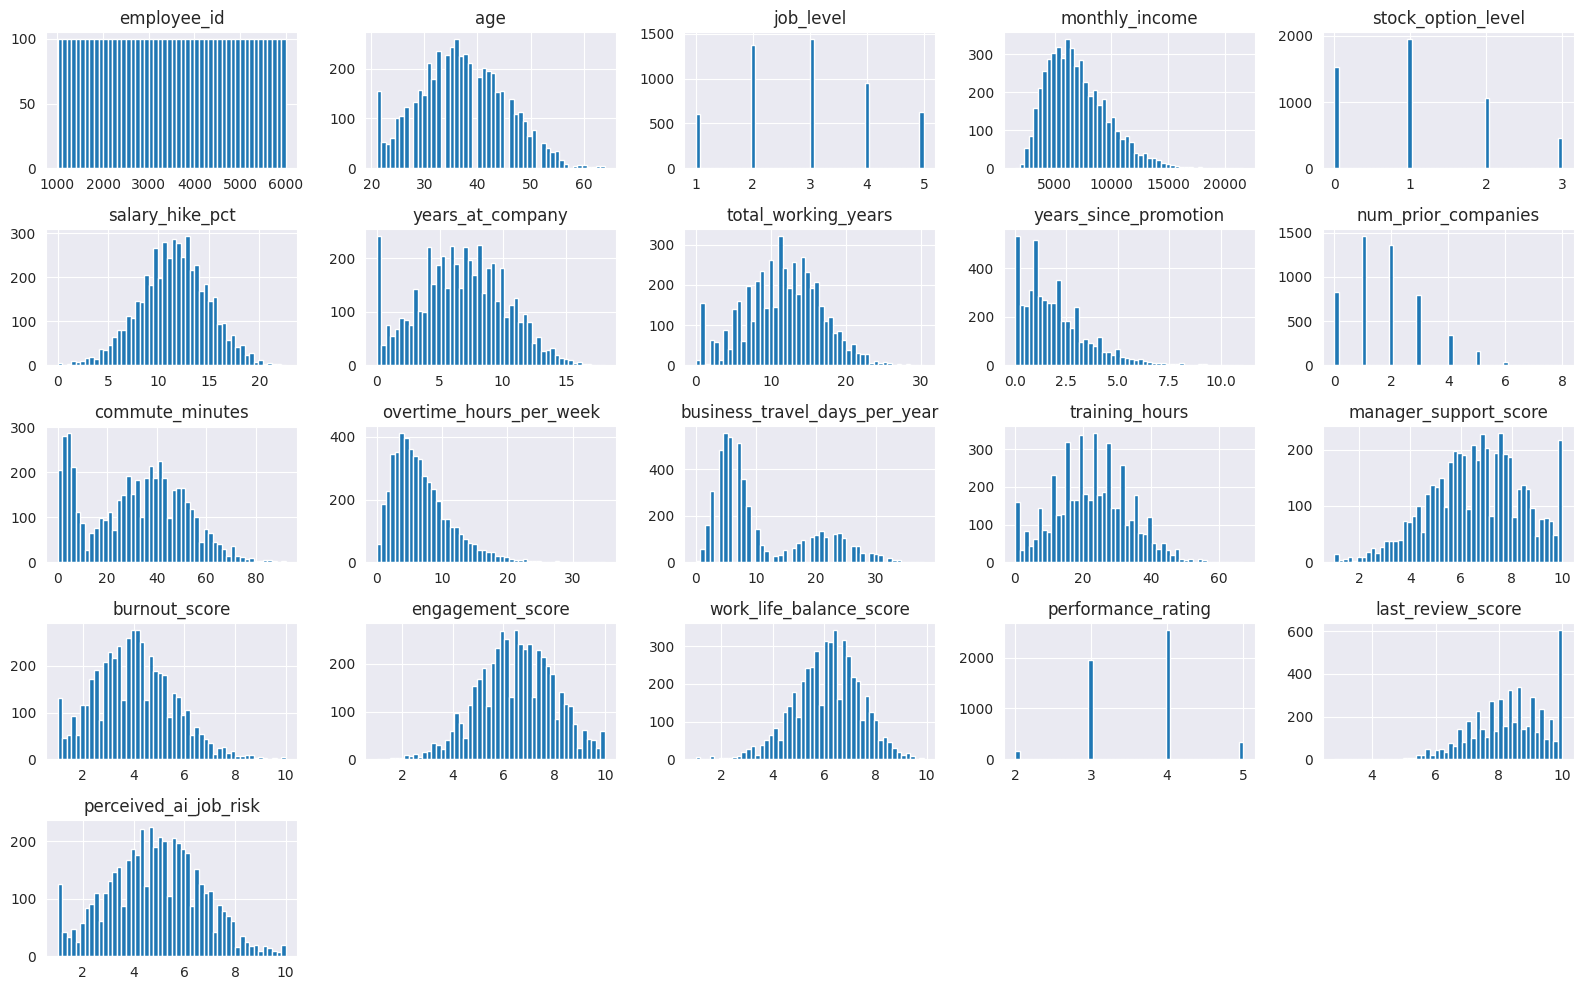

In [72]:
# there are certain skewed metrics but most of it are normally distributed.
employee.hist(figsize=(16,10), bins=50)
plt.tight_layout()
plt.show()

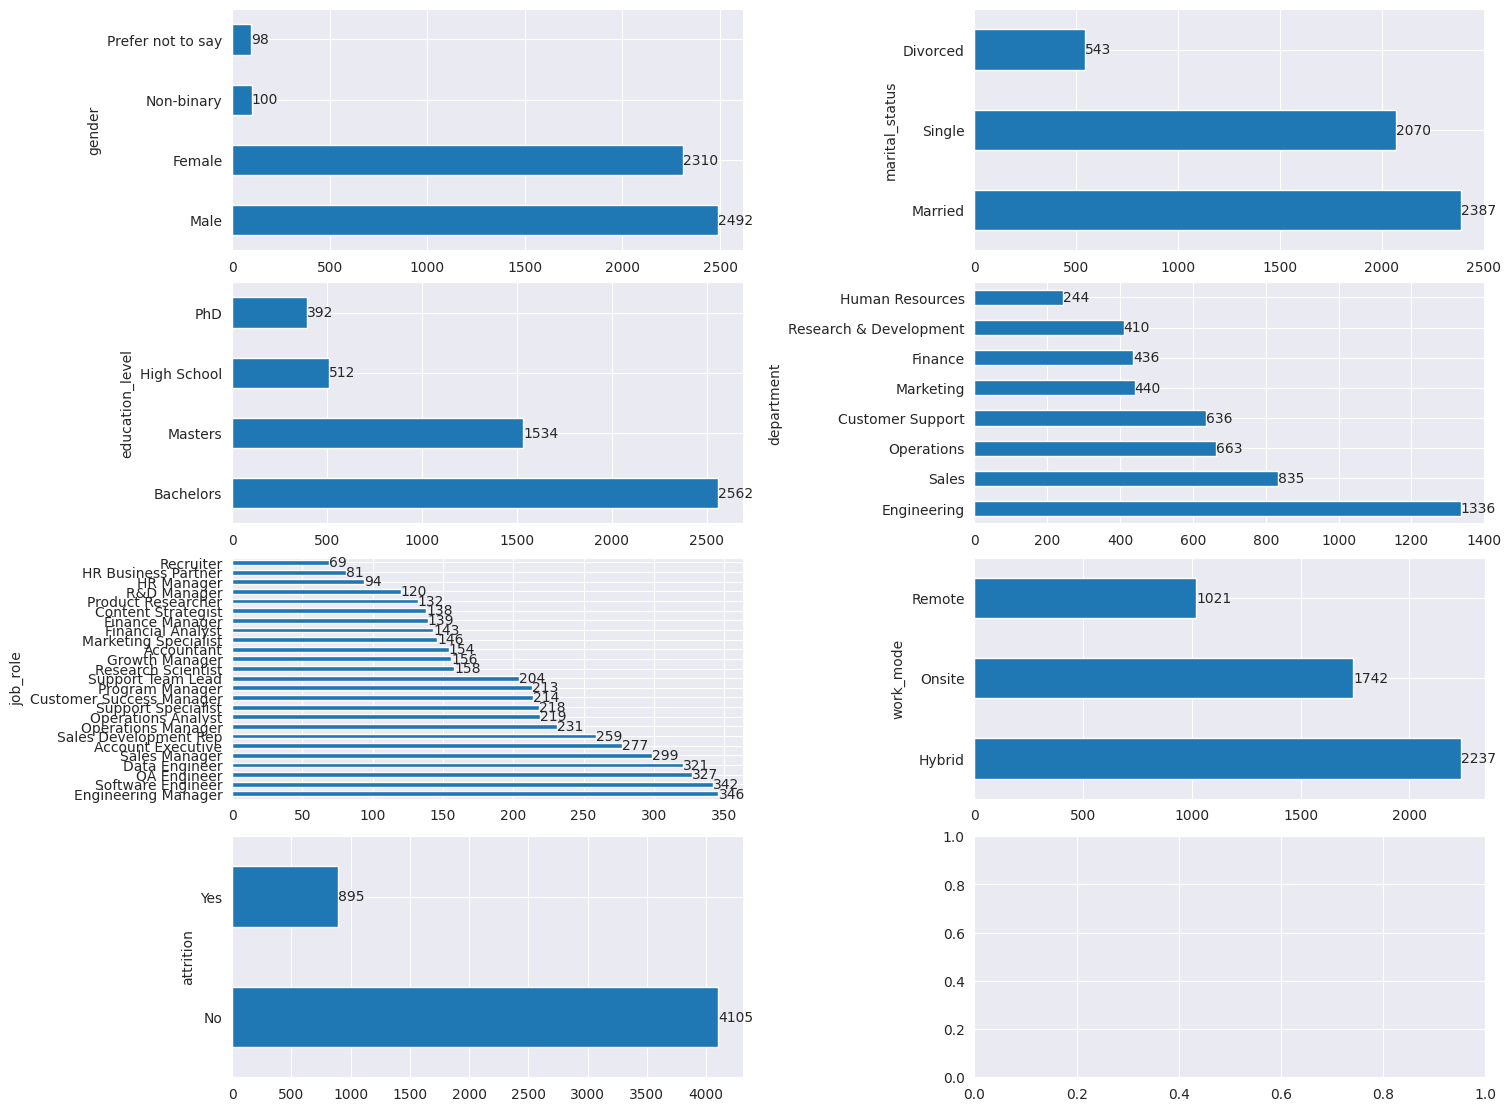

In [73]:
# Ordinal Encoder can be used for education_level since it is interpreted in order, One hot encoder for other categorical columns.
cols = employee.select_dtypes('object').columns
fig, ax = plt.subplots(nrows=4, ncols=2,figsize=(15,11),layout='constrained')
ax = ax.flatten()

for i, col in enumerate(cols):
  employee[col].value_counts().plot(kind='barh', ax=ax[i])
  ax[i].bar_label(ax[i].containers[0])
plt.show()


# Predicting Monthly Income

## Splitting Data

In [74]:
# Splitting Data
# Use job_level as basis for splitting the data.
# job_level is an important feature that can dictate an employee monthly income, it represents his current authority and responsibilities.

X = employee.drop(columns=['monthly_income','employee_id'])
y = employee['monthly_income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=employee['job_level'], random_state=42)

# check proportions for both training and testing sets
pd.merge(
    X_train['job_level'].value_counts(normalize=True).reset_index(name='training_proportion'),
    X_test['job_level'].value_counts(normalize=True).reset_index(name='testing_proportion')
).set_index('job_level')

,training_proportion,testing_proportion
job_level,,
3,0.29,0.29
2,0.28,0.28
4,0.19,0.19
5,0.13,0.13
1,0.12,0.12


## Correlation

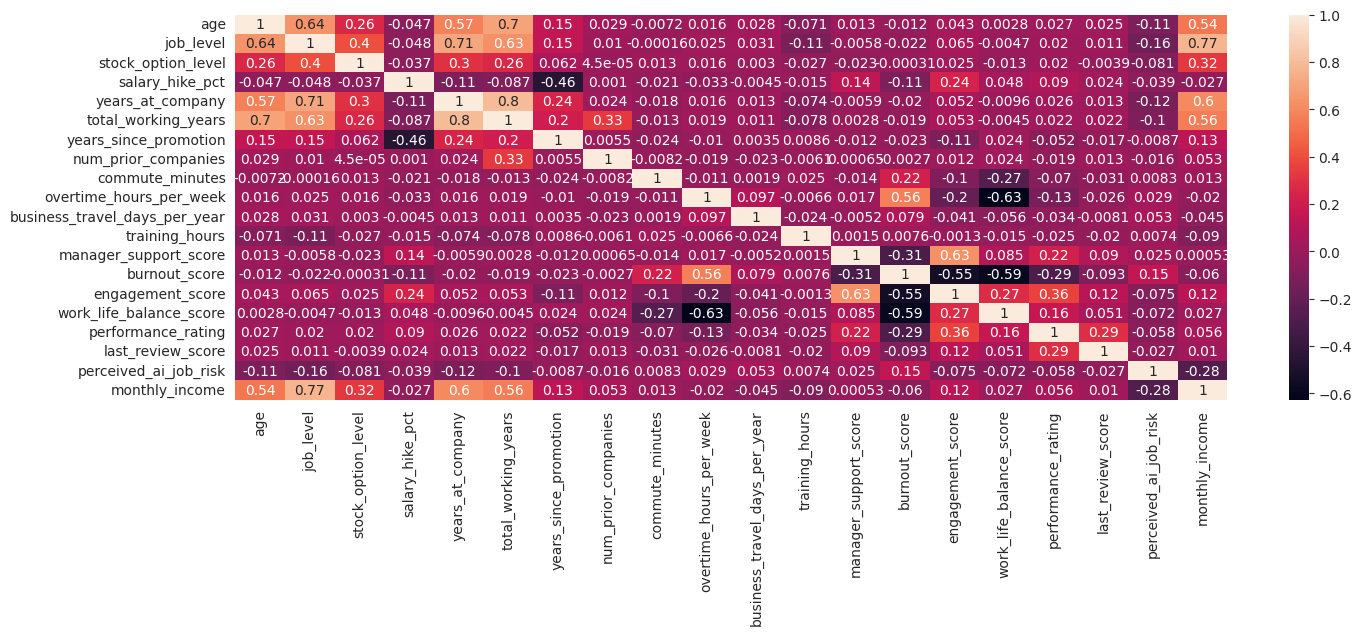

In [75]:
# Correlation
# Strongest correlation for monthly_income are job_level, years_at_company, total_working_years, age, and stock_option_level.
# Multicollinearity is not present.
train = X_train.join(y_train)
plt.figure(figsize=(16,5))
sns.heatmap(train.select_dtypes(np.number).corr(), annot=True)
plt.show()

## Modelling

In [76]:
# define modelling functions.

education_order = ['High School','Bachelors','Masters','PhD']

# pipeline
def create_pipeline( model, skewed_cols, unskewed_cols, cat_cols, order_cols):

    # Generates a custom pipeline dynamically based on the columns provided.
    preprocessor = ColumnTransformer(
        transformers=[
            ("log_transform", FunctionTransformer(np.log1p, feature_names_out="one-to-one"), skewed_cols),
            ("passthrough_features", "passthrough", unskewed_cols),
            ("onehot_encode", OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols),
            ('ordinal_encode', OrdinalEncoder(categories=[education_order]), order_cols)
        ],
        remainder='drop'
    )

    return Pipeline([
        ("prep", preprocessor),
        ("scaler", StandardScaler()),
        ("model", model)
    ])
# metrics
def show_metrics(actual, pred):
    final_rmse = np.sqrt(mean_squared_error(actual, pred))
    final_mae = mean_absolute_error(actual, pred)
    final_r2 = r2_score(actual, pred)
    final_mape = mean_absolute_percentage_error(actual, pred)
    final_20 = percentage_of_error_within_threshold(actual, pred, 20)

    print("RMSE: ",final_rmse)
    print("MAE: ",final_mae)
    print("R2: ", final_r2)
    print("MAPE: ", final_mape)
    print("Percentage of Predicted Values with 20% error and below: ",final_20)

# function for computing percentage of predicted values with (n%) error
def percentage_of_error_within_threshold(actual, pred, percentage):
    abs_resid = np.absolute(actual - pred)
    percentage_error = (abs_resid / actual) * 100
    mask = percentage_error <= percentage
    return percentage_error[mask].count() / actual.shape[0] * 100

In [77]:
# evaluating different models to see which performs better.
X_train_num = X_train.select_dtypes(np.number)
skewness = 0.75
skewed_cols = X_train_num.loc[:,X_train_num.skew() >= skewness].columns
unskewed_cols = X_train_num.loc[:, X_train_num.skew() < skewness].columns
cat_cols = X_train.select_dtypes('object').drop(columns='education_level').columns
order_cols = ['education_level']

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "SGD Regressor": SGDRegressor(penalty=None, random_state=42),
    "Support Vector Regressor": SVR(C=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Ensure target is a Pandas Series so .count() works in percentage_of_error_within_threshold
y_test_series = pd.Series(y_test) if isinstance(y_test, np.ndarray) else y_test


cv_summary = []
for name, model_instance in models.items():
    print(f"\n==================== {name} ====================")


    pipeline = create_pipeline(
        model=model_instance,
        skewed_cols=skewed_cols,
        unskewed_cols=unskewed_cols,
        cat_cols=cat_cols,
        order_cols=order_cols
    )

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    show_metrics(y_test_series, y_pred)

    cv_results = cross_validate(
        estimator=pipeline,
        X=X,
        y=y,
        cv=5,
        scoring={'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'},
        n_jobs=-1
    )

    cv_summary.append({
        "Model": name,
        "CV Mean RMSE": -cv_results['test_rmse'].mean(),
        "CV RMSE Std": cv_results['test_rmse'].std(),
        "CV Mean R2": cv_results['test_r2'].mean()
    })

cv_df = pd.DataFrame(cv_summary).sort_values(by="CV Mean RMSE")
print(cv_df.to_string(index=False))


==================== Linear Regression ====================
RMSE:  1214.5761601085387
MAE:  926.9671820861822
R2:  0.8036352906339046
MAPE:  0.1371031187230176
Percentage of Predicted Values with 20% error and below:  75.5

==================== Ridge Regression ====================
RMSE:  1214.605077509144
MAE:  926.9456469704213
R2:  0.8036259401711687
MAPE:  0.13709385806244356
Percentage of Predicted Values with 20% error and below:  75.5

==================== Lasso Regression ====================
RMSE:  1214.517794422791
MAE:  926.902426443693
R2:  0.803654162543169
MAPE:  0.13709049787239533
Percentage of Predicted Values with 20% error and below:  75.5

==================== SGD Regressor ====================
RMSE:  1222.5203049733902
MAE:  939.4114416108564
R2:  0.8010581755727344
MAPE:  0.13974242993168484
Percentage of Predicted Values with 20% error and below:  75.3

==================== Support Vector Regressor ====================
RMSE:  2749.7247626743724
MAE:  2122.663789

In [78]:
# Gradient Boosting Regressor performed the best in both raw prediction and cross-validation.
# Gradient Boosting Regressor is similar to random forest regressor where each decision tree evaluates,
# the difference is gradient boosting decision trees evaluates the prior decision trees residual errors.
# it continues to correct the error of the first decision tree until the prediction is spot on.

# Based on error metrics, the Gradient Boosting Regressor Model predicted the monthly income of an employee on average higher or lower than 912 dollars.
# The RMSE is 1193 dollars which is close to the value of MAE indicating that the target variable is not heavily skewed.
# R2 score scored higher with 0.81 explaining that 81% of the targets variability is explained by the features.
# MAPE scored lower at 13% which shows that the magnitude of predicted errors is low.

gradient_pipeline = create_pipeline(
        model= GradientBoostingRegressor(random_state=42),
        skewed_cols=skewed_cols,
        unskewed_cols=unskewed_cols,
        cat_cols=cat_cols,
        order_cols=order_cols
    )

gradient_pipeline.fit(X_train, y_train)
y_pred = gradient_pipeline.predict(X_test)

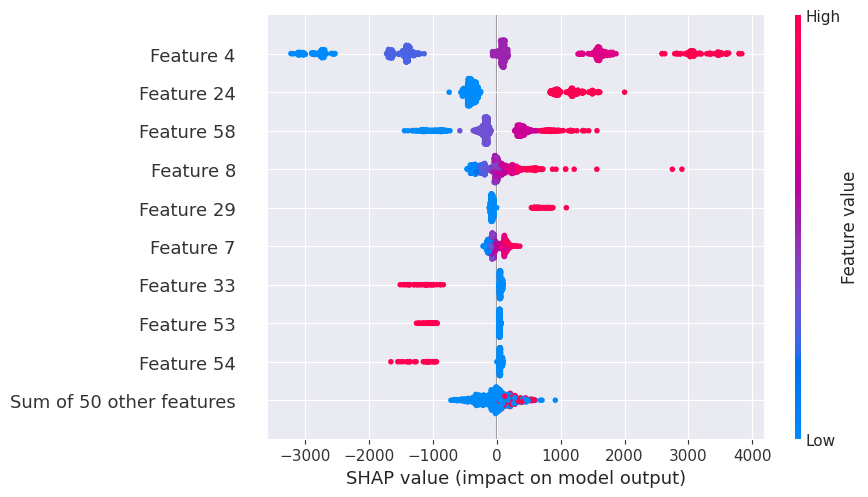

In [79]:
import shap
X_test_transformed = gradient_pipeline[:-1].transform(X_test) # transform X_test using preprocessor and standard scaling

explainer = shap.TreeExplainer(gradient_pipeline['model'])
shap_values = explainer(X_test_transformed)

shap.plots.beeswarm(shap_values)
#shap.plots.bar(shap_values)
#shap.plots.waterfall(shap_values[0])

In [80]:

feature_names = gradient_pipeline[:-1].get_feature_names_out()
print("Feature 4 is:", feature_names[4])
print("Feature 24 is:", feature_names[24])
print("Feature 58 is:", feature_names[58])

# features job_level, department and education_level can strongly predict monthly_income.
# job_level predicts higher value up to 3800 and predicts lower value up to -3200
# department predicts higher value up to 2000 and predicts lower value up to -500
# education_level predicts higher value up to 1500 and predicts lower value up to -1500


Feature 4 is: passthrough_features__job_level
Feature 24 is: onehot_encode__department_Engineering
Feature 58 is: ordinal_encode__education_level


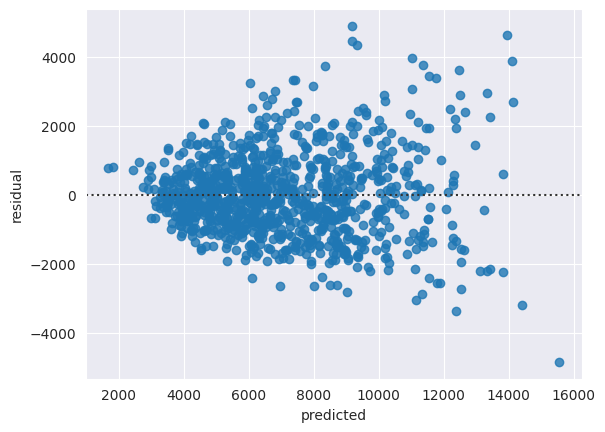

,actual,predicted,residual,absolute,pct_error
2915,14183,"9,163.43","5,019.57","5,019.57",35.39
1864,9311,"6,056.21","3,254.79","3,254.79",34.96
2155,13770,"9,192.53","4,577.47","4,577.47",33.24
3655,13818,"9,337.03","4,480.97","4,480.97",32.43
2131,10746,"7,360.80","3,385.20","3,385.20",31.50
...,...,...,...,...,...
603,2958,"4,549.30","-1,591.30","1,591.30",-53.80
2375,3411,"5,348.12","-1,937.12","1,937.12",-56.79
1680,2874,"4,534.26","-1,660.26","1,660.26",-57.77
4517,4334,"6,949.66","-2,615.66","2,615.66",-60.35


In [81]:
residual = pd.DataFrame({
    'actual' : y_test,
    'predicted' : np.round(y_pred,2),
    'residual' : y_test - y_pred,
    'absolute' : np.absolute(y_test - y_pred),
    'pct_error' : ((y_test - y_pred) / y_test) * 100
}).sort_values('pct_error', ascending=False)

sns.residplot(data=residual, x='predicted', y='residual')
plt.show()

residual

# residual plot shows a fan shape that grows as prediction gets higher in value.
# which makes the regression prediction intervals unreliable.

In [82]:
# filter the underpaid and overpaid employees, set the baseline for residual error at 15% and 5%
underpaid = residual.loc[
    ((residual['pct_error'] >= -15) & (residual['pct_error'] <= -5))
].sort_values('pct_error')
overpaid = residual.loc[
     ( (residual['pct_error'] <= 15) & (residual['pct_error'] >= 5) )
].sort_values('pct_error')

underpaid.shape, overpaid.shape

((180, 5), (197, 5))

In [83]:
# For underpaid employees, engineering department has the highest frequency.
# Salary increase must be applied to underpaid employees with high performance rating, this motivates continued productivity.
# Salary increase must not be applied for underpaid employees with high chance of attrition, low performance rating, and high burnout score,
# increasing might just be a temporary solution or a waste of time and resources.

employee.iloc[underpaid.index].describe(include='all')

,employee_id,age,gender,marital_status,education_level,department,job_role,job_level,monthly_income,stock_option_level,salary_hike_pct,years_at_company,total_working_years,years_since_promotion,num_prior_companies,work_mode,commute_minutes,overtime_hours_per_week,business_travel_days_per_year,training_hours,manager_support_score,burnout_score,engagement_score,work_life_balance_score,performance_rating,last_review_score,uses_ai_tools_at_work,perceived_ai_job_risk,attrition
count,180.00,180.00,180,180,180,180,180,180.00,180.00,180.00,180.00,180.00,180.00,180.00,180.00,180,180.00,180.00,180.00,180.00,180.00,180.00,180.00,180.00,180.00,180.00,180,180.00,180
unique,NaN,NaN,4,3,4,8,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,2
top,NaN,NaN,Female,Single,Bachelors,Engineering,Engineering Manager,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hybrid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,No
freq,NaN,NaN,89,79,92,53,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96,NaN,153
mean,"3,571.88",37.37,NaN,NaN,NaN,NaN,NaN,2.95,"6,461.08",1.12,11.47,6.60,11.84,1.84,1.87,NaN,29.23,5.86,10.28,22.64,6.74,3.83,6.57,6.33,3.62,8.25,NaN,4.78,NaN
std,"1,460.77",8.46,NaN,NaN,NaN,NaN,NaN,1.20,"2,128.31",0.96,3.32,3.64,5.58,1.45,1.38,NaN,19.89,3.95,7.94,10.56,1.95,1.45,1.44,1.19,0.64,1.17,NaN,1.91,NaN
min,"1,002.00",21.00,NaN,NaN,NaN,NaN,NaN,1.00,"2,833.00",0.00,2.70,0.00,0.10,0.00,0.00,NaN,0.00,0.50,1.00,0.00,1.00,1.00,3.00,2.30,2.00,5.00,NaN,1.00,NaN
25%,"2,319.75",32.00,NaN,NaN,NaN,NaN,NaN,2.00,"4,677.75",0.00,9.30,3.98,7.97,0.78,1.00,NaN,8.00,3.08,5.00,15.00,5.50,2.90,5.60,5.60,3.00,7.60,NaN,3.48,NaN
50%,"3,608.50",38.00,NaN,NaN,NaN,NaN,NaN,3.00,"6,166.50",1.00,11.45,6.80,12.70,1.50,2.00,NaN,29.00,5.00,7.00,23.00,6.90,3.90,6.65,6.40,4.00,8.35,NaN,5.05,NaN
75%,"4,914.25",44.00,NaN,NaN,NaN,NaN,NaN,4.00,"7,967.25",2.00,13.90,9.10,15.65,2.70,3.00,NaN,45.00,7.43,16.25,29.00,8.20,4.80,7.50,7.03,4.00,9.10,NaN,5.90,NaN


In [84]:
# For overpaid employees also engineering has the highest frequency.
# Delaying of salary increase for overpaid employees is suggested.
# If reviewed properly, overpaid employees with low burnout rates and high performance rating should receive additional work load to compensate.
# Also, for overpaid employees who uses AI tool at work should also receive additional work load, since AI tools eases up time to finish work.
employee.iloc[overpaid.index].describe(include='all')

,employee_id,age,gender,marital_status,education_level,department,job_role,job_level,monthly_income,stock_option_level,salary_hike_pct,years_at_company,total_working_years,years_since_promotion,num_prior_companies,work_mode,commute_minutes,overtime_hours_per_week,business_travel_days_per_year,training_hours,manager_support_score,burnout_score,engagement_score,work_life_balance_score,performance_rating,last_review_score,uses_ai_tools_at_work,perceived_ai_job_risk,attrition
count,197.00,197.00,197,197,197,197,197,197.00,197.00,197.00,197.00,197.00,197.00,197.00,197.00,197,197.00,197.00,197.00,197.00,197.00,197.00,197.00,197.00,197.00,197.00,197,197.00,197
unique,NaN,NaN,4,3,4,8,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,2
top,NaN,NaN,Male,Married,Bachelors,Engineering,QA Engineer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hybrid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,No
freq,NaN,NaN,108,88,101,65,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,112,NaN,163
mean,"3,675.85",36.94,NaN,NaN,NaN,NaN,NaN,2.89,"7,829.88",1.10,11.44,6.71,11.57,1.83,1.76,NaN,30.82,6.65,10.88,24.01,6.36,4.12,6.30,6.15,3.57,8.33,NaN,4.68,NaN
std,"1,486.87",7.95,NaN,NaN,NaN,NaN,NaN,1.22,"2,604.45",0.90,3.45,3.62,4.79,1.41,1.29,NaN,19.61,4.21,8.53,10.78,2.03,1.48,1.62,1.27,0.65,1.09,NaN,1.95,NaN
min,"1,025.00",21.00,NaN,NaN,NaN,NaN,NaN,1.00,"3,240.00",0.00,0.30,0.00,1.00,0.00,0.00,NaN,0.00,0.10,0.00,0.00,1.00,1.00,2.10,1.70,2.00,5.40,NaN,1.00,NaN
25%,"2,420.00",31.00,NaN,NaN,NaN,NaN,NaN,2.00,"5,769.00",0.00,9.30,4.30,8.80,0.80,1.00,NaN,13.00,3.90,5.00,17.00,5.00,3.10,5.20,5.40,3.00,7.70,NaN,3.30,NaN
50%,"3,868.00",36.00,NaN,NaN,NaN,NaN,NaN,3.00,"7,275.00",1.00,11.60,6.60,11.50,1.60,2.00,NaN,33.00,5.90,7.00,24.00,6.30,4.00,6.20,6.20,4.00,8.40,NaN,4.50,NaN
75%,"5,004.00",43.00,NaN,NaN,NaN,NaN,NaN,4.00,"9,816.00",2.00,13.50,9.10,14.00,2.50,2.00,NaN,46.00,8.50,17.00,31.00,7.70,5.00,7.50,6.90,4.00,9.10,NaN,6.00,NaN


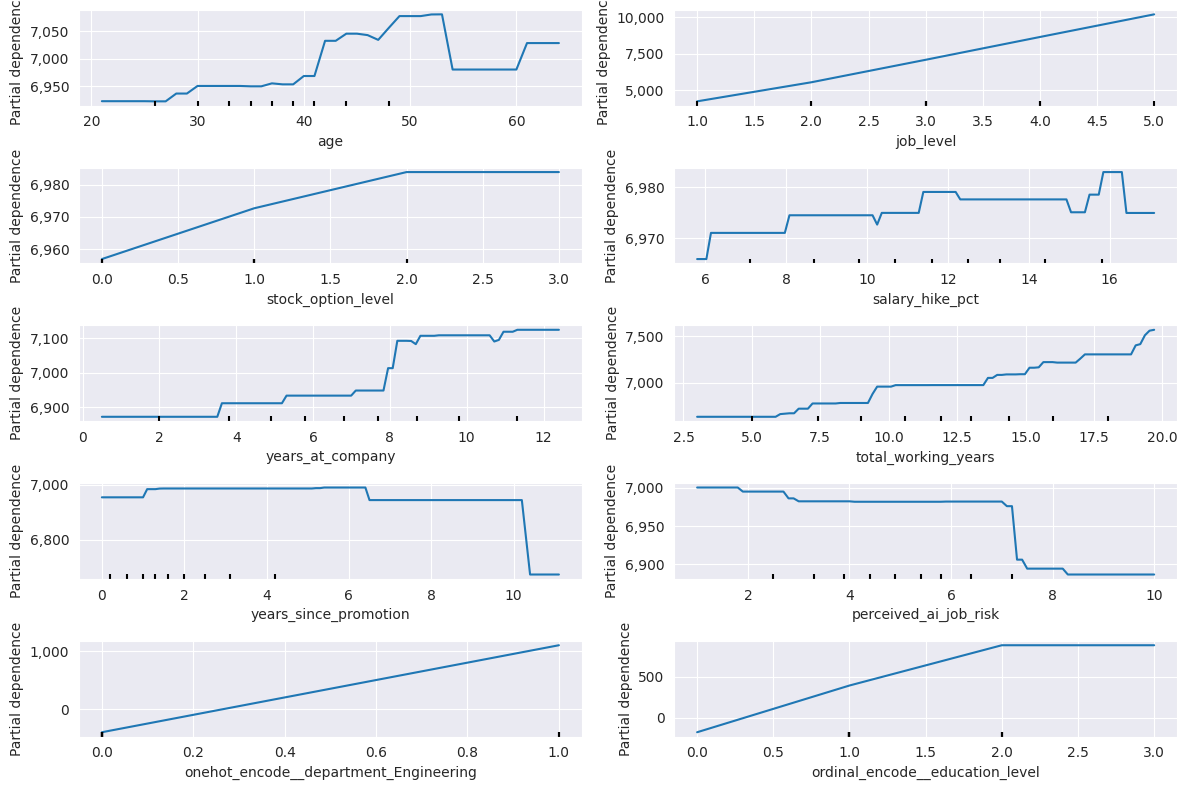

In [85]:

from sklearn.inspection import PartialDependenceDisplay
import matplotlib.ticker as ticker

X_train_transformed = gradient_pipeline['prep'].transform(X_train)
feature_names = gradient_pipeline['prep'].get_feature_names_out()
X_train_transformed_df = pd.DataFrame( # this creates the exact preprocessed dataset that was used in the model.
    X_train_transformed,
    columns=feature_names,
    index=X_train.index
)

# plotting
fig, ax = plt.subplots(nrows =5, ncols=2, figsize=(12,8))
ax = ax.flatten()
cols = ['age','job_level','stock_option_level', 'salary_hike_pct',
        'years_at_company', 'total_working_years','years_since_promotion','perceived_ai_job_risk']
transformed_cols = ['onehot_encode__department_Engineering']

for i, col in enumerate(cols):

  PartialDependenceDisplay.from_estimator(
      estimator=gradient_pipeline,
      X=X_train,
      features=[col],
      ax = ax[i]
  )
  plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))


PartialDependenceDisplay.from_estimator(
      estimator=gradient_pipeline['model'],
      X=X_train_transformed_df,
      features=[transformed_cols],
      ax = ax[8]
  )
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

PartialDependenceDisplay.from_estimator(
      estimator=gradient_pipeline['model'],
      X=X_train_transformed_df,
      features=[['ordinal_encode__education_level']],
      ax = ax[9]
  )
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

# in all employee metrics, job_level has the highest increase in monthly salary. on average it increases 1500 dollars per 1 job level increase.
# being in the engineering department increases average salary by 1000 dollars comapred to other departments.
